In [ ]:
import numpy as np
import matplotlib.pyplot as plt 

In [33]:
def integral(f, a, b, n):
    return regla_trapecio_compuesta(f, a, b, n)

def Fourier(f, x, L, n, n_integral=1000):

    def f_cos(t):
        return f(t)*np.cos(n_f*np.pi/L * t)
    
    def f_sen(t):
        return f(t)*np.sin(n_f*np.pi/L * t)
    
    a0 = 1 / L * integral(f, -L, L, n)
    result = a0/2

    a_vals, b_vals = [], []

    for i in range(n):
        n_f = i+1
        a = (1 / L) * integral(f_cos, -L, L, n_integral)
        b = 1 / L * integral(f_sen, -L, L, n_integral)
        a_vals.append(a)
        b_vals.append(b)
        result += a * np.cos((i+1)* np.pi/L * x)+b *np.sin((i+1)*np.pi/L * x)

    return result, a0, a_vals, b_vals

# Práctica 2

## Ejercicio 5

Implementar una función que estime una integral a través de una regla de trapecios compuesta. Debe recibir la función a integrar, el intervalo de integración y el número de intervalos de la partición.

$$\int_{a}^{b}{f(x) dx} \sim \frac{h}{2} [f(a)+2f(a+h)+2f(a+2h)+...+f(b)]$$

In [3]:
def regla_trapecio_compuesta(f, a, b, n):
    if n <= 0:
        raise ValueError()

    h = (b - a) / n
    suma = f(a) + f(b)

    for i in range(1, n):
        x_i = a + i * h
        suma += 2 * f(x_i)

    return h/2 * suma

In [6]:
# Probamos con un ejemplito

def f(x):
    return np.sin(x)

# Intervalo de integración
a = 0
b = np.pi

# Número de subintervalos
n = 10

# Cálculo de la integral aproximada
resultado = regla_trapecio_compuesta(f, a, b, n)

print(f"Resultado aproximado: {resultado}")
print(f"Error absoluto: {abs(2 - resultado)}")

Resultado aproximado: 1.9835235375094546
Error absoluto: 0.01647646249054535


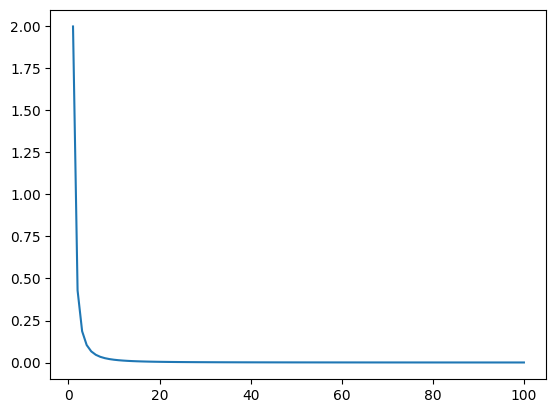

In [12]:
errores = []
indices = []
for i in range(1, 101):
    result = regla_trapecio_compuesta(f, a, b, i)
    errores.append(abs(2 - result))
    indices.append(i)

plt.plot(indices, errores)
plt.show()


## Ejercicio 6

Probar el algoritmo del ejercicio anterior integrando la función $f(x) = e^{-x^{2}}$ cuya integral en toda la recta es $\sqrt{π}$.

In [15]:
def f6(x):
    return np.exp(-x**2)

result = regla_trapecio_compuesta(f6, -10000, 10000, 200000)
print(f"El resultado de la integral aproximado es: {result}")
print(f"El resultado de la integral real es: {np.sqrt(np.pi)}")


El resultado de la integral aproximado es: 1.7724538509055165
El resultado de la integral real es: 1.7724538509055159


## Ejercicio 7

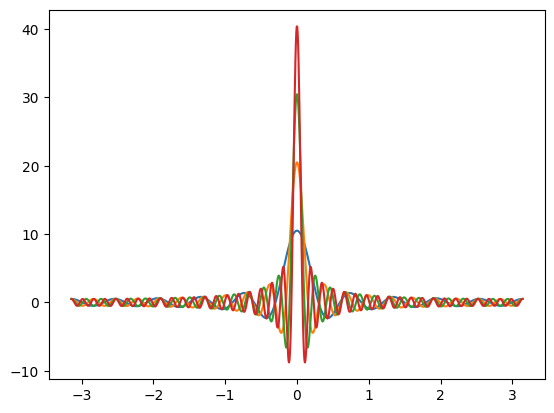

In [21]:
N = [10, 20, 30, 40]

def dirichlet(t):
    return np.sin((n+1/2)*t)/(2*np.sin(t/2))

t=np.linspace(-np.pi, np.pi, 1000)

for n in N:
    plt.plot(t, dirichlet(t))
plt.show()

In [24]:
for n in N:
    n=n
    print(f"Aproximación del área del núcleo de Dirichlet para N = {n} : {regla_trapecio_compuesta(dirichlet, -np.pi, np.pi, 100)/np.pi}")


Aproximación del área del núcleo de Dirichlet para N = 10 : 1.0000000000000002
Aproximación del área del núcleo de Dirichlet para N = 20 : 1.000000000000002
Aproximación del área del núcleo de Dirichlet para N = 30 : 1.0000000000000022
Aproximación del área del núcleo de Dirichlet para N = 40 : 1.0000000000000009


## Ejercicio 9

Utilizando el ejercicio anterior, calcular aproximaciones por polinomios trigono-métricos de la función $f(x) = x^{4}$. Graficar $f$ y sus aproximaciones sucesivas.

In [25]:
def f9(x):
    return x**4

2
5
10
100


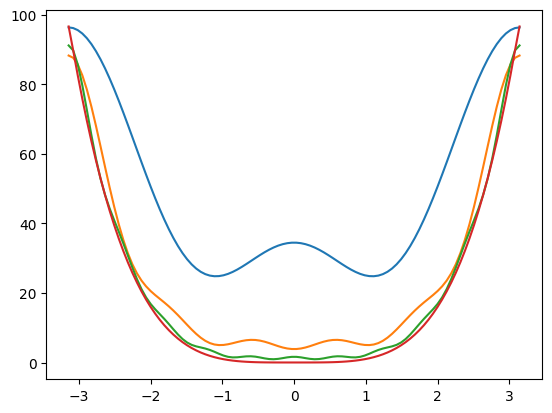

In [34]:
N = [2, 5, 10, 100]


for n in N:
    print(n)
    X_vals = np.linspace(-np.pi, np.pi, 100)
    result = [Fourier(f9, x, np.pi, n)[0] for x in X_vals]
    plt.plot(X_vals, result)

plt.show()

## Ejercicio 10

Utilizando el Ejercicio 13 de la práctica (teórica) graficar polinomios trigonométricos de distinto grado que aproximen a las funciones $f(x) = x$ y $f(x) = x^{2}$. ¿Qué se observa en cada caso? ¿Por qué?

In [36]:
def f10_1(x):
    return x

2
5
10
100


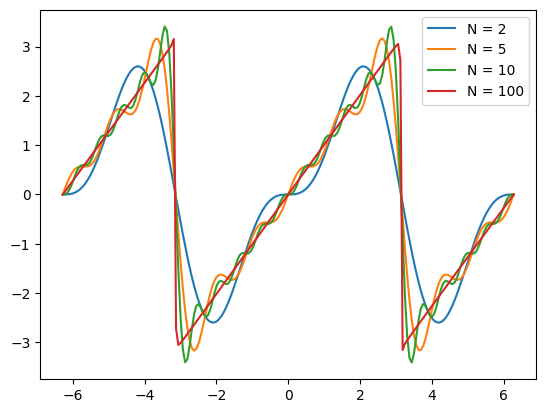

In [41]:
N = [2, 5, 10, 100]

for n in N:
    print(n)
    X_vals = np.linspace(-2*np.pi, 2*np.pi, 200)
    result = [Fourier(f10_1, x, np.pi, n)[0] for x in X_vals]
    plt.plot(X_vals, result, label=f'N = {n}')


plt.legend()
plt.show()